In [ ]:
# Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Load the Dataset
df = pd.read_csv("../dataset/heart.csv")

# Display the first 5 rows
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [3]:
# Dataset Shape
print(df.shape)

(918, 12)


In [4]:
# Statistical Summary
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [5]:
# Check Missing Values
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [ ]:
# Check class distribution

print(df["HeartDisease"].value_counts())

print("\nPercentage Distribution:")
print(df["HeartDisease"].value_counts(normalize=True) * 100)

In [6]:
# Separate features and target

X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (918, 11)
Target Shape: (918,)


In [7]:
# Import preprocessing libraries

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [8]:
# Numerical columns

numerical_features = [
    "Age",
    "RestingBP",
    "Cholesterol",
    "FastingBS",
    "MaxHR",
    "Oldpeak"
]

# Categorical columns

categorical_features = [
    "Sex",
    "ChestPainType",
    "RestingECG",
    "ExerciseAngina",
    "ST_Slope"
]

In [9]:
# Create preprocessing pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [10]:
# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Training Samples:", X_train.shape)
print("Testing Samples:", X_test.shape)

Training Samples: (642, 11)
Testing Samples: (276, 11)


In [11]:
# Import model and pipeline

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [12]:
# Create Logistic Regression pipeline

logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(random_state=42))
])

In [13]:
# Train the Logistic Regression model

logistic_pipeline.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [14]:
# Predict on test data

y_pred_lr = logistic_pipeline.predict(X_test)

In [15]:
# Import evaluation metrics

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [16]:
# Evaluate Logistic Regression

accuracy = accuracy_score(y_test, y_pred_lr)
print("Accuracy:", round(accuracy, 4))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.8841

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.84      0.87       123
           1       0.88      0.92      0.90       153

    accuracy                           0.88       276
   macro avg       0.89      0.88      0.88       276
weighted avg       0.88      0.88      0.88       276



In [17]:
# Display confusion matrix

cm = confusion_matrix(y_test, y_pred_lr)
print("Confusion Matrix:\n")
print(cm)

Confusion Matrix:

[[103  20]
 [ 12 141]]


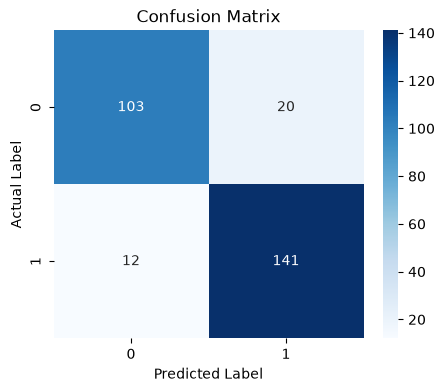

In [18]:
# Plot confusion matrix

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

In [19]:
# Import Random Forest model

from sklearn.ensemble import RandomForestClassifier

In [20]:
# Create Random Forest pipeline

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

In [ ]:
# Train Random Forest model

rf_pipeline.fit(X_train, y_train)
print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [22]:
# Make predictions

y_pred_rf = rf_pipeline.predict(X_test)

In [23]:
# Evaluate Random Forest model

rf_accuracy = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", round(rf_accuracy, 4))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9022

Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.87      0.89       123
           1       0.90      0.93      0.91       153

    accuracy                           0.90       276
   macro avg       0.90      0.90      0.90       276
weighted avg       0.90      0.90      0.90       276



In [24]:
# Compare model performance

comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [accuracy, rf_accuracy]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.884058
1,Random Forest,0.902174


In [25]:
# Find the best model

best_model = comparison.loc[comparison["Accuracy"].idxmax()]
print("Best Model:", best_model["Model"])
print("Accuracy:", round(best_model["Accuracy"], 4))

Best Model: Random Forest
Accuracy: 0.9022


In [26]:
# Import cross validation

from sklearn.model_selection import cross_val_score

In [52]:
# Perform cross validation for Logistic Regression

lr_cv_scores = cross_val_score(
    logistic_pipeline,
    X,
    y,
    cv=5,
    scoring="accuracy"
)
print("Logistic Regression CV Scores:")
print(lr_cv_scores)
print("\nAverage Accuracy:", round(lr_cv_scores.mean(), 4))
print("Standard Deviation:", round(lr_cv_scores.std(), 4))

Logistic Regression CV Scores:
[0.85326087 0.83695652 0.83152174 0.8579235  0.76502732]

Average Accuracy: 0.8289
Standard Deviation: 0.0334


In [53]:
# Perform cross validation for Random Forest

rf_cv_scores = cross_val_score(
    rf_pipeline,
    X,
    y,
    cv=5,
    scoring="accuracy"
)
print("Random Forest CV Scores:")
print(rf_cv_scores)
print("\nAverage Accuracy:", round(rf_cv_scores.mean(), 4))
print("Standard Deviation:", round(rf_cv_scores.std(), 4))

Random Forest CV Scores:
[0.89673913 0.82065217 0.83152174 0.83606557 0.7704918 ]

Average Accuracy: 0.8311
Standard Deviation: 0.0403


In [29]:
# Compare cross validation results

cv_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Average CV Accuracy": [
        lr_cv_scores.mean(),
        rf_cv_scores.mean()
    ]
})

cv_results

,Model,Average CV Accuracy
0,Logistic Regression,0.828938
1,Random Forest,0.831094


In [30]:
# Import GridSearchCV

from sklearn.model_selection import GridSearchCV

In [31]:
# Define parameter grid

param_grid = {
    "classifier__n_estimators": [50, 100],
    "classifier__max_depth": [5, 10, None]
}

In [32]:
# Create GridSearchCV object

grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

In [33]:
# Train GridSearchCV

grid_search.fit(X_train, y_train)
print("Grid Search completed!")

Grid Search completed!


In [34]:
# Display best parameters

print("Best Parameters:")
print(grid_search.best_params_)
print("\nBest Cross Validation Score:")
print(round(grid_search.best_score_, 4))

Best Parameters:
{'classifier__max_depth': 5, 'classifier__n_estimators': 50}

Best Cross Validation Score:
0.8567


In [35]:
# Get the best model

best_model = grid_search.best_estimator_

In [36]:
# Make predictions using the best model

y_pred_best = best_model.predict(X_test)

In [37]:
# Evaluate the best model

best_accuracy = accuracy_score(y_test, y_pred_best)
print("Best Model Accuracy:", round(best_accuracy, 4))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_best))

Best Model Accuracy: 0.8986

Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.85      0.88       123
           1       0.89      0.93      0.91       153

    accuracy                           0.90       276
   macro avg       0.90      0.89      0.90       276
weighted avg       0.90      0.90      0.90       276



In [38]:
# Compare all models

final_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Optimized Random Forest"
    ],
    "Accuracy": [
        accuracy,
        rf_accuracy,
        best_accuracy
    ]
})

final_results

,Model,Accuracy
0,Logistic Regression,0.884058
1,Random Forest,0.902174
2,Optimized Random Forest,0.898551


In [39]:
# Get feature names after preprocessing

feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

In [40]:
# Create feature importance dataframe

importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": best_model.named_steps["classifier"].feature_importances_
})
importance = importance.sort_values(by="Importance", ascending=False)
importance.head(10)

,Feature,Importance
19,cat__ST_Slope_Up,0.231170
18,cat__ST_Slope_Flat,0.121949
5,num__Oldpeak,0.091916
16,cat__ExerciseAngina_Y,0.091221
15,cat__ExerciseAngina_N,0.082087
8,cat__ChestPainType_ASY,0.076043
2,num__Cholesterol,0.065533
4,num__MaxHR,0.053033
0,num__Age,0.037945
1,num__RestingBP,0.030595


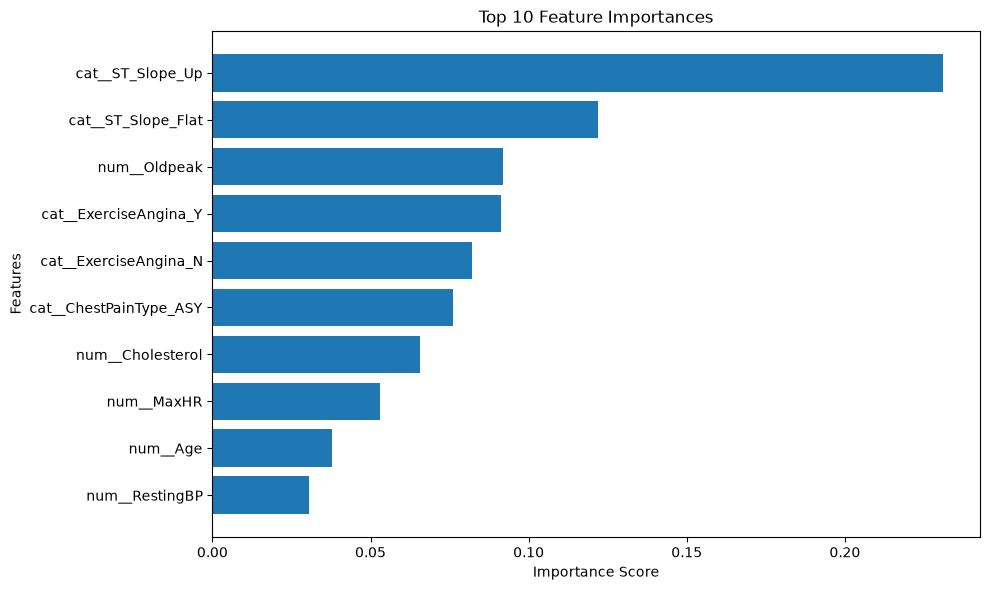

In [41]:
# Plot top 10 important features

plt.figure(figsize=(10, 6))
plt.barh(
    importance["Feature"][:10],
    importance["Importance"][:10]
)
plt.title("Top 10 Feature Importances")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [42]:
# Import joblib

import joblib

In [50]:
joblib.dump(best_model, "models/heart_disease_model.pkl")

print("Model saved successfully!")

Model saved successfully!
